In [1]:
library(Seurat)
library(PaaSc)
library(tidyverse)
library(ROCit)

Attaching SeuratObject

Warning message:
“replacing previous import ‘data.table::shift’ by ‘tictoc::shift’ when loading ‘CelliD’”
── Attaching core tidyverse packages ───────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ─────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
# Load the PBMC dataset
pbmc.data <- Read10X(data.dir = "filtered_gene_bc_matrices/hg19/")
object <- CreateSeuratObject(counts = pbmc.data, project = "pbmc3k", min.cells = 3, min.features = 200)

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


Computing Fuzzy Matrix



1.991 sec elapsed


Computing SVD



11.383 sec elapsed


Computing Coordinates



0.617 sec elapsed


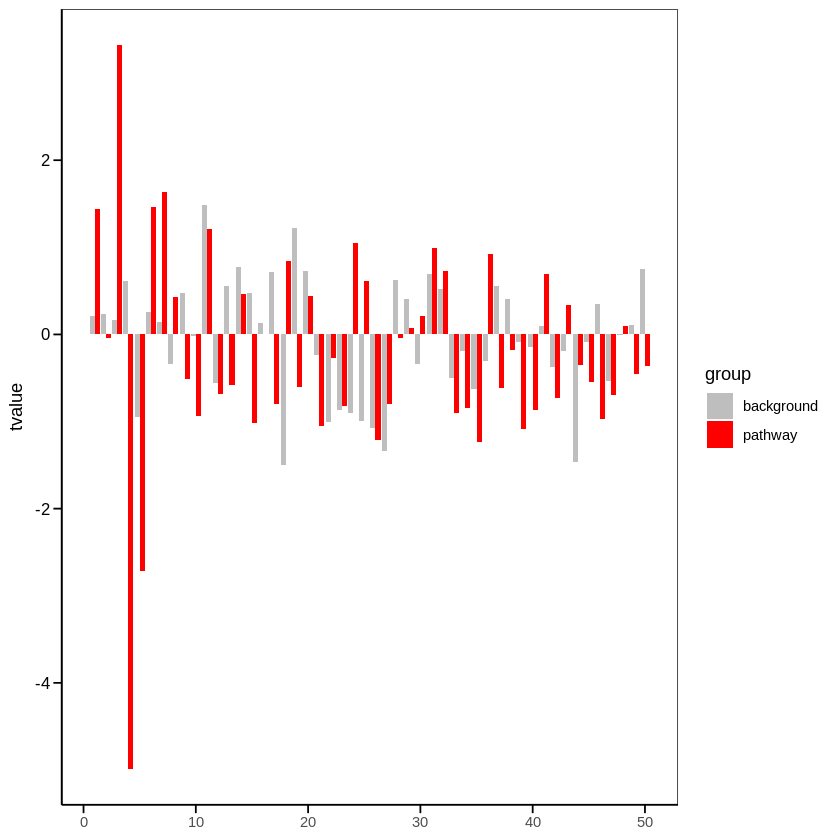

In [3]:
#---SupFig1A---#
object <- computeMCA(object, nmcs = 50)
background_geneset <- "Tres.kegg"
B_cell_activation <- readLines("B_cell_activation.txt")
pathway_geneset <- list(B_cell_activation = B_cell_activation)
gene_rate <- getGeneRate(background.geneset = background_geneset, pathway.geneset = pathway_geneset)
rdata <- doRegression(object, gene.rate = gene_rate)
out <- data.frame(tvalue = c(rdata[1,], rdata[2,]),
				  pvalue = c(rdata[3,], rdata[4,]),
				  mca = colnames(rdata),
				  Factor = as.integer(gsub('mca_', '', colnames(rdata))),
				  group = c(rep('pathway', ncol(rdata)), rep('background', ncol(rdata)))
				  )

SupFig1A <- ggplot(out, aes(x = Factor, y = tvalue, fill = group)) + 
		 geom_bar(stat="identity", position = position_dodge(width = 0.9), width = 0.9) + 
		 theme_bw() + scale_fill_manual(values = c("grey", "red")) + 
	     theme(panel.grid = element_blank(),panel.background=element_blank(),
	        	axis.ticks.length = unit(5,'pt'),axis.line=element_line(color="black"),
	            axis.title.x = element_blank(),
	            axis.text.y = element_text(color="black",size=10),
	            axis.ticks = element_line(color="black"))
SupFig1A
#ggsave(file = 'SupFig1A.pdf',SupFig1A, width = 6, height = 3)

In [4]:
###compute PaaSc score
object <- computeMCA(object, nmcs = 20)
regression_data <- doRegression(object, gene.rate = gene_rate)
score_data <- computeScore(object, regression.data = regression_data, weight = FALSE, normalize = "z-score")
head(score_data)
# Ceiling score for better visualization
cscore <- score_data[colnames(object), 1]
cscore[cscore > quantile(cscore, 0.99)] = quantile(cscore, 0.99)
cscore[cscore < quantile(cscore, 0.01)] = quantile(cscore, 0.01)
object@meta.data$B_cell_activation <- cscore

Computing Fuzzy Matrix



1.48 sec elapsed


Computing SVD



4.224 sec elapsed


Computing Coordinates



0.609 sec elapsed


,B_cell_activation
,<dbl>
AAACATACAACCAC-1,-0.34147588
AAACATTGAGCTAC-1,2.09843787
AAACATTGATCAGC-1,-1.10499865
AAACCGTGCTTCCG-1,0.04372992
AAACCGTGTATGCG-1,0.24766909
AAACGCACTGGTAC-1,-0.24327916


In [5]:
# pre-process
object <- FindVariableFeatures(object, verbose = FALSE)
object <- ScaleData(object, verbose = FALSE)
object <- RunPCA(object, verbose = FALSE)
object <- FindNeighbors(object, verbose = FALSE)
object <- RunUMAP(object, dims = 1:20, verbose = FALSE)
annotation_file <- "pbmc3k_seurat_annotation.txt.gz"
seurat_annotations <- read.table(annotation_file, header = TRUE, row.names = 1, sep = "\t")
object@meta.data$seurat_annotations <- seurat_annotations[sub("-.*", "", colnames(object)), ]

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


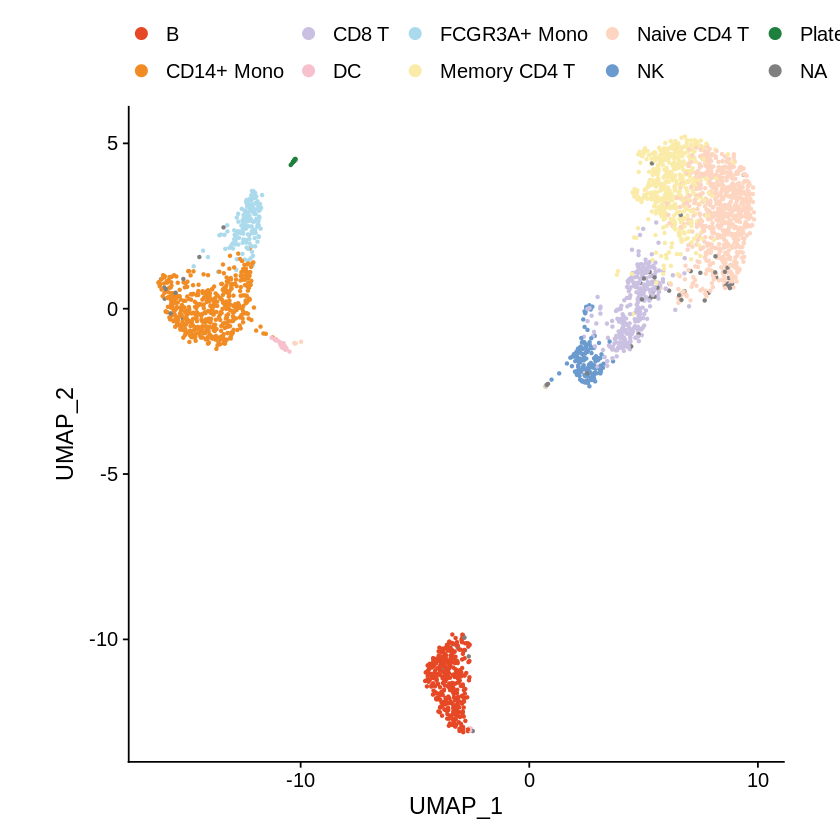

In [6]:
#---SupFig1B---#
colors=c('#E64825','#F18C25','#CAC0E1','#F6C0CC','#ABDAEC','#FAECA8','#FDD5C0','#6A9ACE','#1E803D','grey')
SupFig1B <- DimPlot(object, group.by = "seurat_annotations",cols = colors,size=5)+
                  labs(title = NULL)  + 
                  theme(aspect.ratio = 1,legend.position = 'top')
SupFig1B
#ggsave(file = 'SupFig1B.pdf',SupFig1B, width = 3, height = 3)

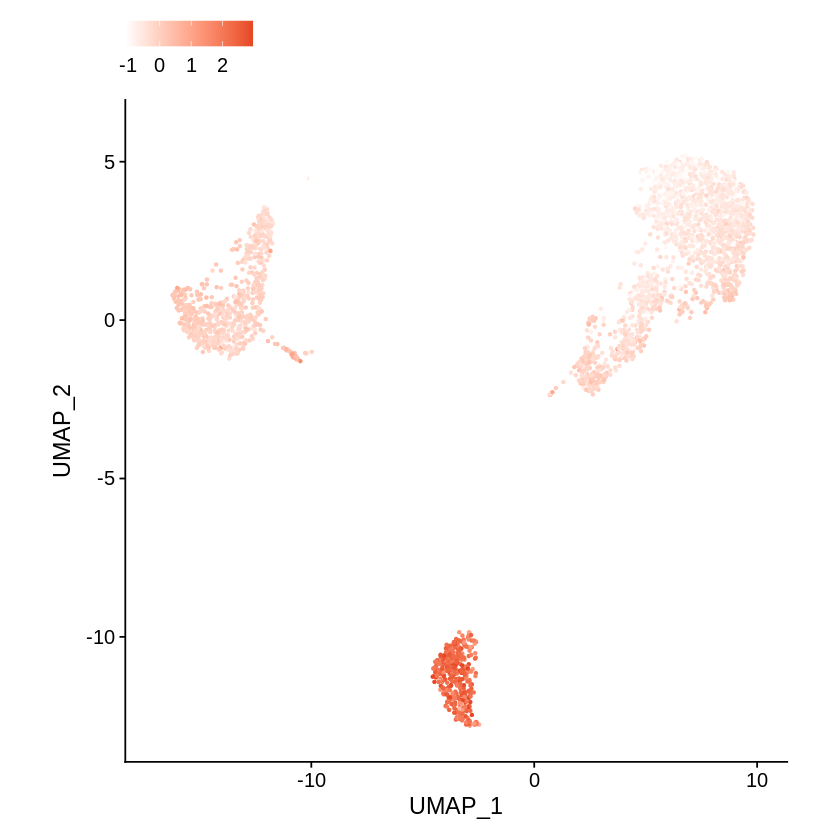

In [7]:
#---SupFig1C---#
SupFig1C <- FeaturePlot(object, features = "B_cell_activation", cols = c('white', '#E64825'))+ 
  labs(title = NULL)  + 
theme(aspect.ratio = 1,legend.position = 'top')
SupFig1C
#ggsave(file = 'SupFig1C.pdf',SupFig1C, width = 3, height = 3)

number of iterations= 13 


Warning message:
“Removed 3 rows containing non-finite outside the scale range (`stat_density()`).”


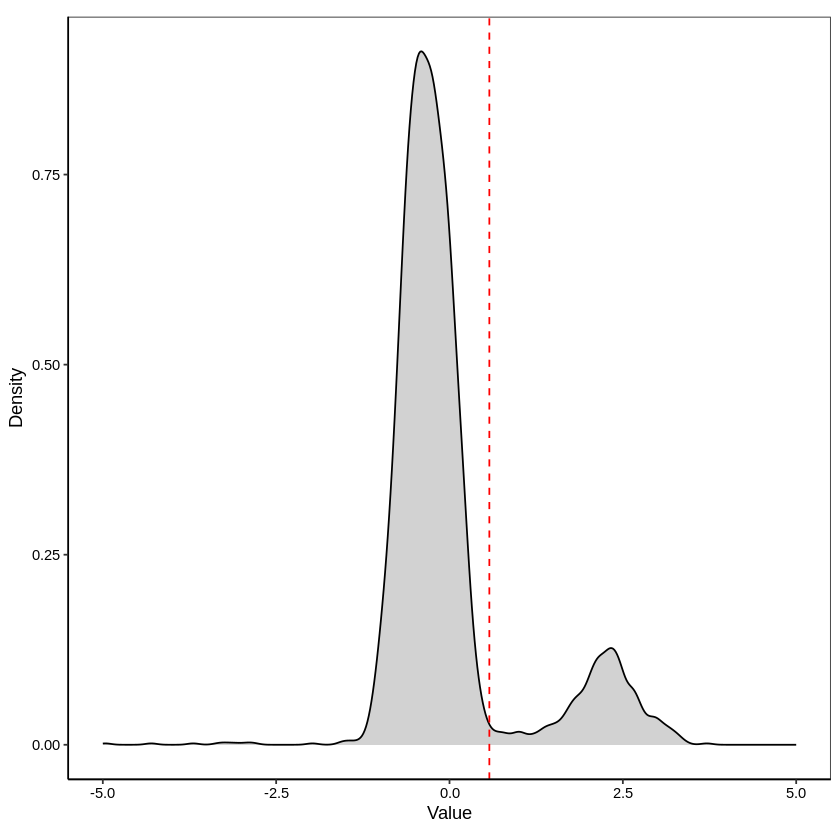

In [8]:
set.seed(1)
label_data <- doBinarization(score_data, n.cluster = 2, method = "GMM")
threshold <- min(score_data[rownames(label_data[label_data['B_cell_activation.label'] == 'positive', ]), 'B_cell_activation'])
#---SupFig1D---#
SupFig1D <- ggplot(score_data, aes(x = B_cell_activation)) + geom_density(fill = "grey", alpha = 0.7) + theme_bw() +
	theme(panel.grid = element_blank(),aspect.ratio = 1,
		  axis.line = element_line(color = "black"),
	      axis.text = element_text(color = "black")) +
	geom_vline(xintercept = threshold, color = "red", linetype = "dashed") + xlim(-5,5) +
	labs(x = "Value", y = "Density")
SupFig1D
#ggsave(file = 'SupFig1D.pdf',SupFig1D, width = 3, height = 3)

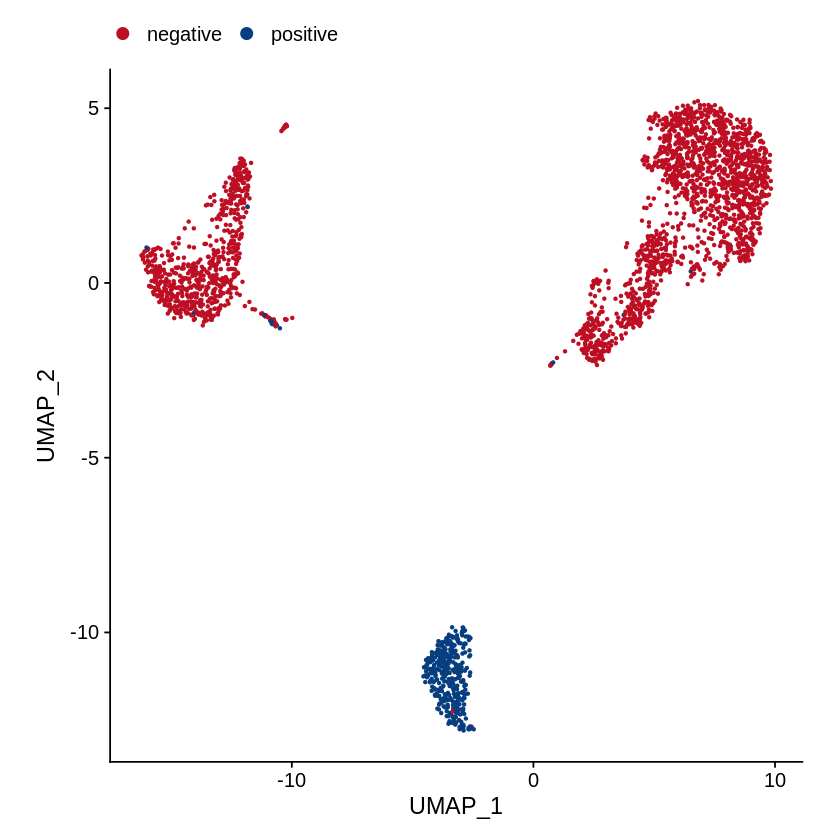

In [9]:
object@meta.data$B_cell_activation_label <- label_data[colnames(object), ]
#---SupFig1E---#
SupFig1E <- DimPlot(object, group.by = "B_cell_activation_label",cols=c('#BE0E23','#073E7F'))+
  labs(title = NULL)  + 
theme(aspect.ratio = 1,legend.position = 'top')
SupFig1E
#ggsave(file = 'SupFig1E.pdf',SupFig1E, width = 3, height = 3)

Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range (`geom_point()`).”


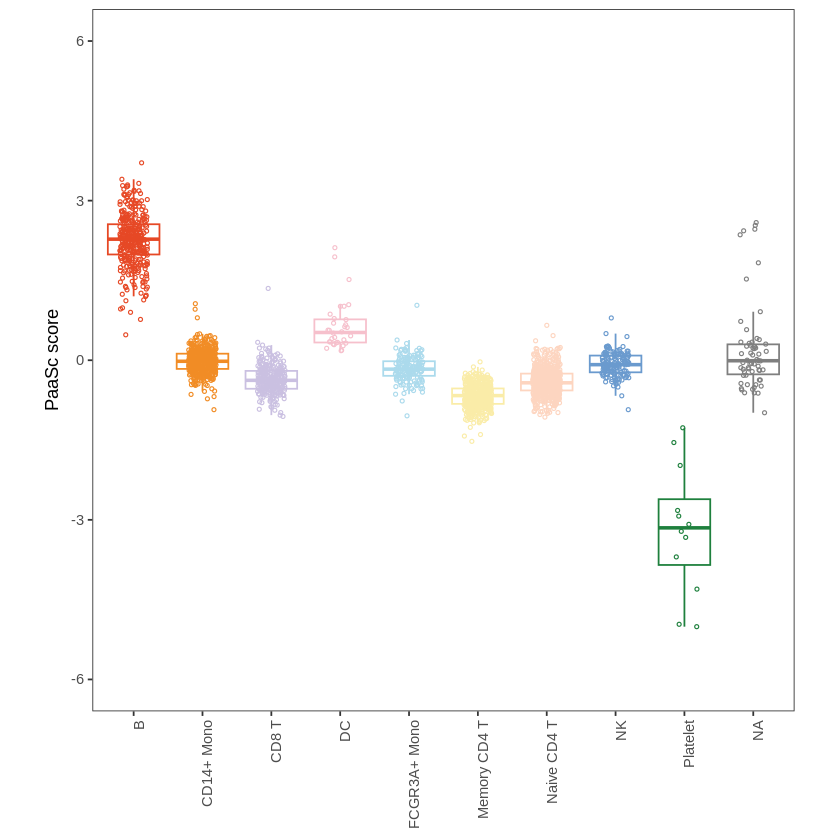

In [10]:
score_data_withanno <- cbind(score_data, seurat_annotations)
#---SupFig1F---#
SupFig1F<- ggplot(score_data_withanno, aes(x = seurat_annotations, y = B_cell_activation, color = seurat_annotations)) + 
    scale_color_manual(values = colors)+ ylim(-6,6) +
    labs(x=NULL,y='PaaSc score')+
    geom_boxplot(outlier.shape = NA) + geom_jitter(width = 0.2, size = 0.8,shape = 1) + theme_bw() + 
    theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank()) + 
    theme(plot.title = element_text(hjust = 0.5)) + theme(legend.title=element_blank()) + 
    theme(legend.position="none") +  
    theme(aspect.ratio = 1,axis.text.x = element_text(vjust = 1, hjust = 1, angle = 90)
         )
SupFig1F
#ggsave(file = 'SupFig1F.pdf',SupFig1F, width = 3, height = 3)

                            
 Method used: empirical     
 Number of positive(s): 344 
 Number of negative(s): 2356
 Area under curve: 0.9981   


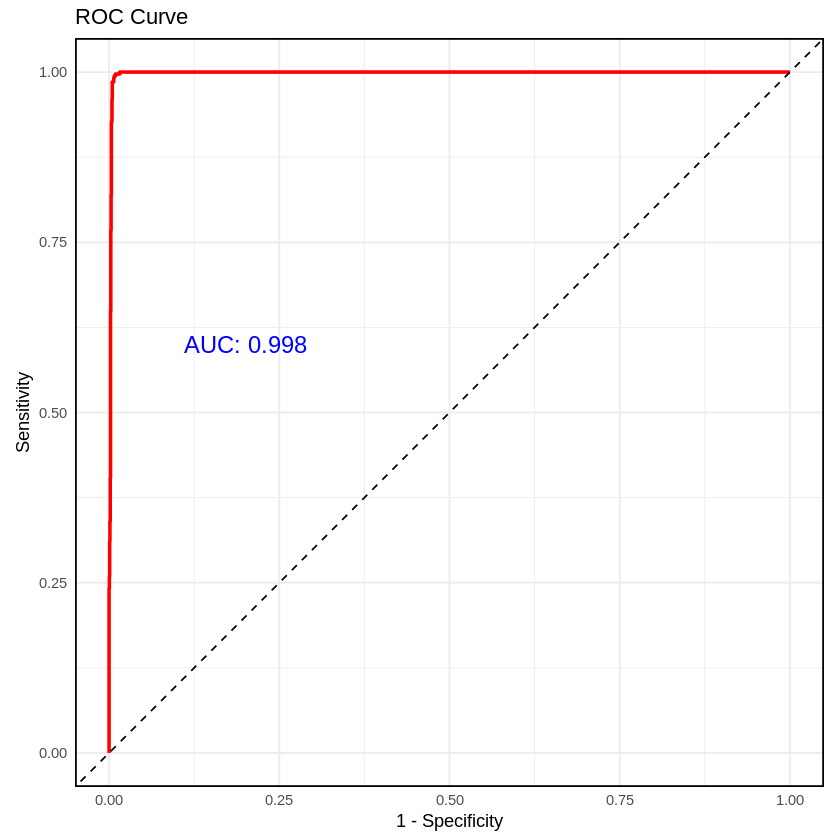

In [11]:
label <- rep('others', nrow(score_data_withanno))
label[score_data_withanno$seurat_annotations == "B"] <- "B"
roc_empirical <- rocit(score = score_data_withanno$B_cell_activation, class = label, negref = "others")

auc_value <- as.numeric(strsplit(as.character(summary(roc_empirical)[4,]), ":")[[1]][2])
auc_label <- paste0("AUC: ", round(auc_value, 3))  

roc_df <- data.frame(
  TPR = roc_empirical$TPR,  
  FPR = roc_empirical$FPR   
)
#---SupFig1G---#
SupFig1G <- ggplot(roc_df, aes(x = FPR, y = TPR)) +
  geom_line(color = "red", linewidth = 1) +  
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "black") +  
  annotate("text", x = 0.2, y = 0.6, label = auc_label, size = 5, color = "blue") +  
  labs(title = "ROC Curve", x = "1 - Specificity", y = "Sensitivity") +
  theme_minimal()+ theme(aspect.ratio = 1,panel.border = element_rect(color = "black", fill = NA, linewidth = 1))
SupFig1G
#ggsave(file = 'SupFig1G.pdf',SupFig1G, width = 3, height = 3)